In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn as sk
from sklearn.metrics import r2_score, mean_squared_error

### Task: Connect to "Python training characteristics" table in GCP and load it into this python environment

In [2]:
df = pd.read_csv("eqfx_customers_data.csv")
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

<ipython-input-2-5f9c34f345a7>:1: DtypeWarning: Columns (10,11,13,15,17,18,22,23,24,25,30,34,35,39,40,42,43,50,51,54,60,63,67,69,76,78,80,82,83,86,89,101,102,103,108,109,112,113,118,119,122,125,129,130,133,134,136,137,139,179,197,198,205,209,221,239,240,241,242) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("eqfx_customers_data.csv")


,outref10,efx_gbflag,efx_weight,RNISF05,RNILF05,EIILF52,EIILF51,ZSC009,ZSC060,ZSQ009,...,SSQ16,CSC3,CSC40,CSC41,CSC51,LSQ072,LSC250,LSC350,LSC599,LSC251
0,1000280528,1,1.727625,450,435,191,215,4.99,-1.04,4.99,...,M,M,M,M,M,C,15,23,1650,99
1,1000576212,0,1.000000,431,431,196,234,-0.84,-0.03,-0.84,...,M,M,M,M,M,C,11,15,36900,99
2,1000793119,1,1.727625,454,439,188,234,6.42,0.38,6.42,...,M,M,M,M,M,C,17,26,4950,99
3,1000014856,0,6.252772,369,395,233,281,3.29,-1.35,3.29,...,1,M,M,M,M,C,14,21,6850,99
4,1000103116,0,1.000000,505,537,183,197,-0.5,1.15,-0.5,...,C,M,M,M,M,C,19,36,18550,99


In [3]:
df.info()
df = df.apply(pd.to_numeric, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74718 entries, 0 to 74717
Columns: 242 entries, outref10 to LSC251
dtypes: float64(1), int64(6), object(235)
memory usage: 138.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74718 entries, 0 to 74717
Columns: 242 entries, outref10 to LSC251
dtypes: float64(236), int64(6)
memory usage: 138.0 MB


In [4]:
descriptions = pd.read_csv("cleaner_headers.csv")
#descriptions.drop(["Unnamed: 0", "Sequence number"], axis=1, inplace=True)
descriptions.head()

,Code,Unnamed: 0,Description
0,RNISF05,0,All Markets RN 5 Full RN Opt in subject and as...
1,RNILF05,1,All Markets RN 5 Full RN Opt in subject and as...
2,CSC3,2,CCJ-First Applicant-Current Address: Number of...
3,CSC40,3,CCJ-First Applicant-Current Address: Number of...
4,CSC51,4,CCJ-First Applicant-Current Address: Number of...


# Improving Data Quality and Predictive modelling:
## **Equifax Customer credit account data**

# Tasked with initial Hypothesis to test:

The higher the credit card limit has been raised in the last 12 months, the more likely the client is interested in opening a new credit card account.

**Objectives**

*   Obj1: What are the ethical concerns with such a project? How can these be mitigated?
*   Obj2: Identify the fields that are most applicable to testing this hypothesis.
*   Obj3: What data quality issues do these fields?
* Obj4 : Is there a significant relationship between the two, can it be quantified?

## Obj 1 : What are the ethical concerns with such a project? How can these be mitigated?

Discuss this amongst your colleagues and include here some points about risks/concerns and how you intend to mitigate them

## Obj2 : Identify the fields that are most applicable to testing this hypothesis
- **BSQ612** (First Applicant-All Address: Trended Credit Card Total Limit Last 12 Months)
- **LSQ469** (First Applicant-All Address: Open to buy L1m [Credit Cards])

In [5]:
print(df["BSQ612"].info())
df["LSQ469"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74718 entries, 0 to 74717
Series name: BSQ612
Non-Null Count  Dtype  
--------------  -----  
66417 non-null  float64
dtypes: float64(1)
memory usage: 583.9 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 74718 entries, 0 to 74717
Series name: LSQ469
Non-Null Count  Dtype  
--------------  -----  
65945 non-null  float64
dtypes: float64(1)
memory usage: 583.9 KB


## Obj 3 - What data quality issues do these fields possess?

### Task: How complete and duplicated are these two fields?


In [6]:
print(df[["BSQ612","LSQ469"]].count())
df1 = df.dropna(subset=["BSQ612","LSQ469"])
df1.duplicated().sum()

BSQ612    66417
LSQ469    65945
dtype: int64


np.int64(0)

In [7]:
df1.iloc[: , :20].info()

<class 'pandas.core.frame.DataFrame'>
Index: 65945 entries, 0 to 74715
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   outref10    65945 non-null  int64  
 1   efx_gbflag  65945 non-null  int64  
 2   efx_weight  65945 non-null  float64
 3   RNISF05     65945 non-null  int64  
 4   RNILF05     65945 non-null  int64  
 5   EIILF52     65945 non-null  int64  
 6   EIILF51     65945 non-null  int64  
 7   ZSC009      37598 non-null  float64
 8   ZSC060      37598 non-null  float64
 9   ZSQ009      37818 non-null  float64
 10  ZSQ010      37818 non-null  float64
 11  ZSC013      36364 non-null  float64
 12  ZSC004      37398 non-null  float64
 13  ZSC007      36437 non-null  float64
 14  ZSQ004      37821 non-null  float64
 15  ZSC006      37598 non-null  float64
 16  ZSQ006      37818 non-null  float64
 17  ZSC012      33343 non-null  float64
 18  ZSC008      31308 non-null  float64
 19  LSQ321      33740 non-null  fl

## Obj4 : Is there a significant relationship between the two, can it be quantified?

1. Calculate the Correlation coefficient of the relevant fields
2. Confirm there is a linear relationship, this with a visualisation of the fields relationship

In [8]:
df1[["BSQ612","LSQ469"]].corr()

,BSQ612,LSQ469
BSQ612,1.000000,0.828476
LSQ469,0.828476,1.000000


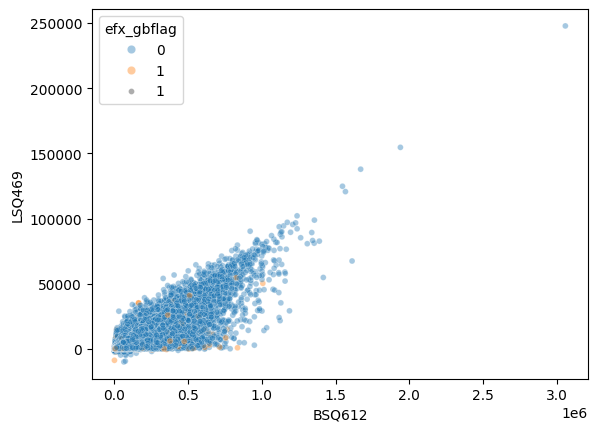

In [9]:
sns.scatterplot(data = df1, x = "BSQ612", y= "LSQ469", hue="efx_gbflag", alpha=0.4, size=1);

<Axes: >

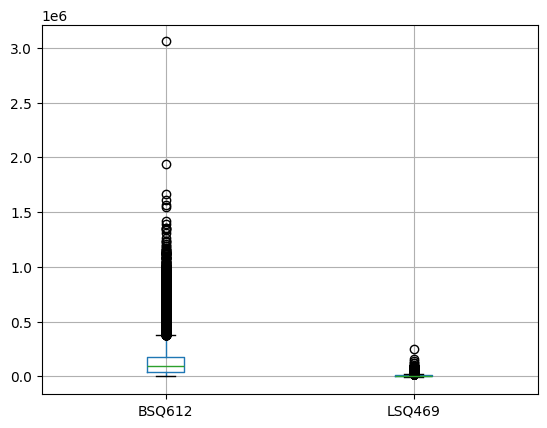

In [10]:
df1[["BSQ612","LSQ469"]].boxplot()

In [11]:
df1[["BSQ612","LSQ469"]].describe()

,BSQ612,LSQ469
count,6.594500e+04,65945.000000
mean,1.352617e+05,6889.038032
std,1.368341e+05,9229.502441
min,0.000000e+00,-9992.000000
25%,4.420000e+04,1116.000000
50%,9.340000e+04,3641.000000
75%,1.788000e+05,8922.000000
max,3.058600e+06,247789.000000


What insights can you take away from this data exploration?
- Should the dataset be scaled?
- Should we remove outliers identified inn the boxplots?
- What sort of relationship is there between the two fields?

# Building your Model

Regression model is viable but would require a domain expert or published research to verify the causal link between the two fields. Otherwise its correlation without causation.

At the very least there is a strong assoiciation between seeking higher credit limits and opening new accounts.

**Simple Linear Regression Modelling**: provided we know how much credit has increased for a customer in the last 12 months, we can reliably predict how likely the customer is interested in a new credit account. A model will mathematically define the relationship between the two fields, to demonstrate the strength of this relationship

### Task: Split your data into Training and Testing

In [12]:
from sklearn.model_selection import train_test_split

# Select the columns for the model
df_model = df1[['BSQ612', 'LSQ469']].dropna()

# Define features (X) and target (y)
X = df_model[['BSQ612']]
y = df_model['LSQ469']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (52756, 1)
Testing features shape: (13189, 1)
Training target shape: (52756,)
Testing target shape: (13189,)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select the columns for the model
df_model = df1[['BSQ612', 'LSQ469']].dropna()

# Define features (X) and target (y)
X = df_model[['BSQ612']]
y = df_model['LSQ469']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#converting to dataframe
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Print shapes
print("Training features shape (scaled):", X_train.shape)
print("Testing features shape (scaled):", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training features shape (scaled): (52756, 1)
Testing features shape (scaled): (13189, 1)
Training target shape: (52756,)
Testing target shape: (13189,)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 7660.901523436119
Intercept: 6867.935703995754


R-squared: 0.67
Mean Squared Error: 27753504.77


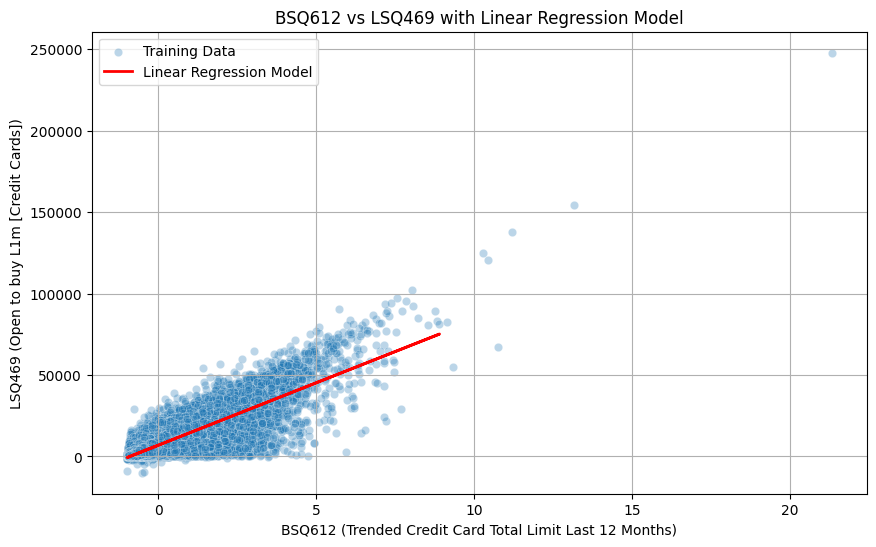

In [15]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R-squared: {r2:.2f}')
print(f'Mean Squared Error: {mse:.2f}')


# Visualize the data and the model

# Scatter plot of the training data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['BSQ612'], y=y_train, label='Training Data', alpha=0.3)

# Plot the regression line from the trained model
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Model')

plt.title('BSQ612 vs LSQ469 with Linear Regression Model')
plt.xlabel('BSQ612 (Trended Credit Card Total Limit Last 12 Months)')
plt.ylabel('LSQ469 (Open to buy L1m [Credit Cards])')
plt.legend()
plt.grid(True)
plt.show()

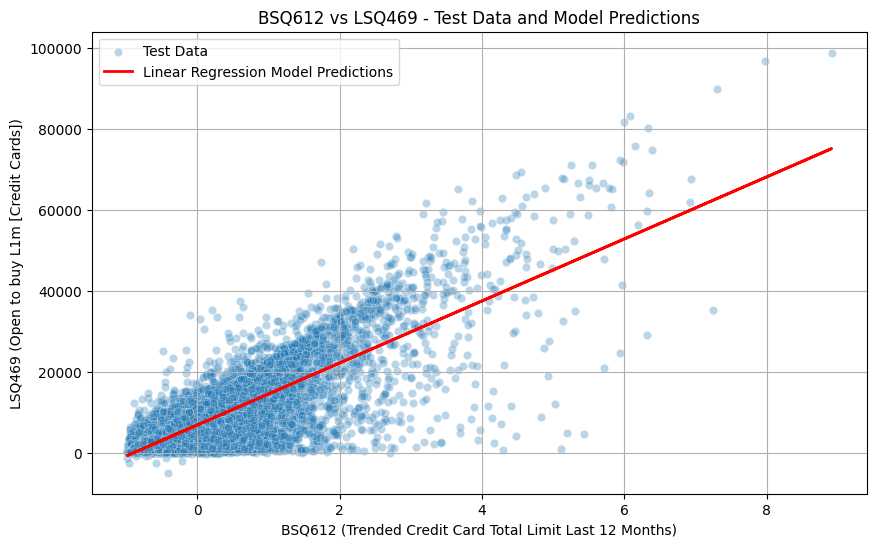

In [16]:
# Scatter plot of the test data and predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['BSQ612'], y=y_test, label='Test Data', alpha=0.3)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Model Predictions')
plt.title('BSQ612 vs LSQ469 - Test Data and Model Predictions')
plt.xlabel('BSQ612 (Trended Credit Card Total Limit Last 12 Months)')
plt.ylabel('LSQ469 (Open to buy L1m [Credit Cards])')
plt.legend()
plt.grid(True)
plt.show()

# Perform regression and residual analysis

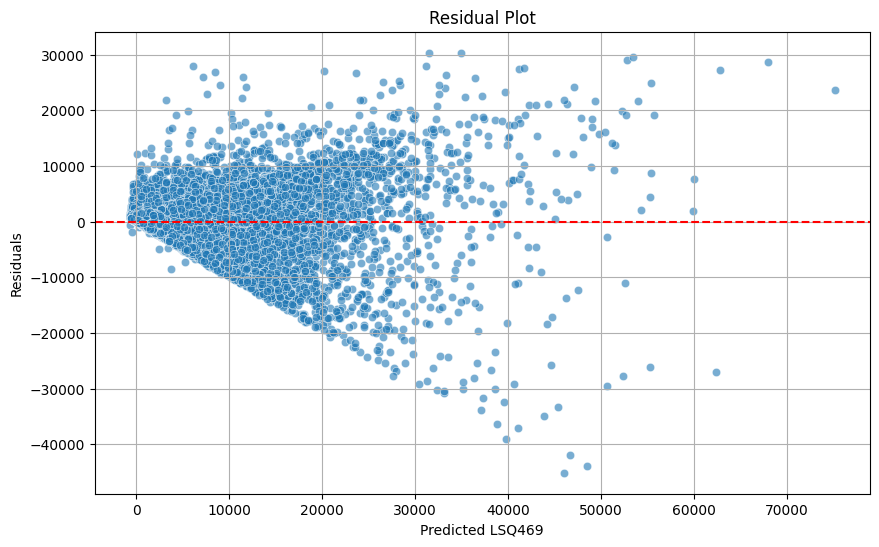

R-squared: 0.67
Mean Squared Error: 27753504.77
Coefficient: 7660.901523436119
Intercept: 6867.935703995754


In [17]:
# Residual analysis
residuals = y_test - y_pred

# Plotting the residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted LSQ469')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


# Check for constant variance (homoscedasticity) visually from the residual plot.
# The residual plot should show random scattering of points around the zero line.

# Check for independence of residuals
# For time series data, you might use autocorrelation plots (ACF).
# For non-time series, visually inspecting the residual plot for patterns is common.

# Summary of model performance
print(f'R-squared: {r2:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

In [18]:
#residuals**2
np.mean(residuals)

np.float64(17.004964505897465)

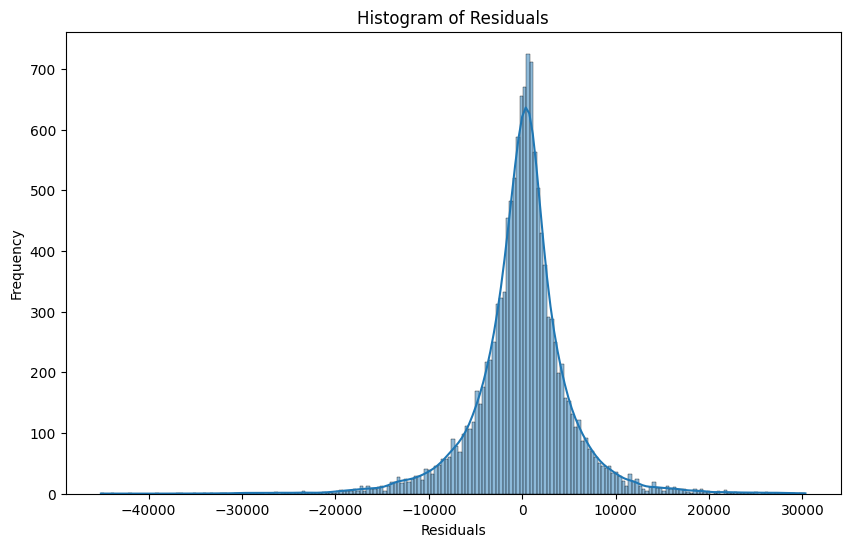

In [19]:
# Plot histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

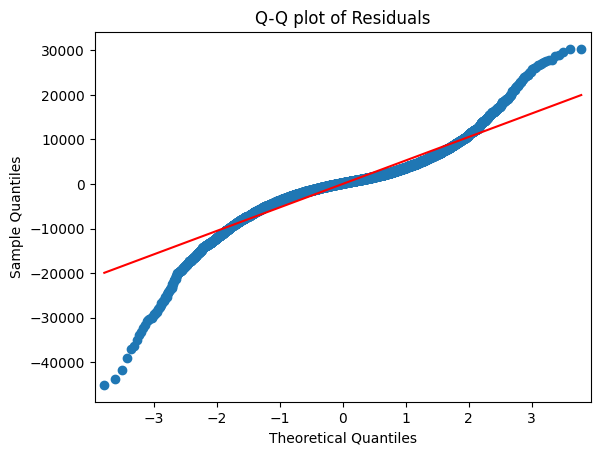

In [20]:
# Quantile-Quantile plot (Q-Q plot) of residuals
import statsmodels.api as sm
import pylab as py

sm.qqplot(residuals, line='s') # 's' for standardized line
py.title('Q-Q plot of Residuals')
py.show()

**Conclusion** - Quantified by Coefficient: 0.0556 and
Intercept: -707.438. So that for every 100 units increase of BSQ, we see a 5.5 unit increase for LSQ.  

Answered the hypothesis but there is little utility in such a predictive model. We ought to predict a KPI or some core metric that describes client outcomes.


---



## **Task:** Build a Regression model that can be used to infer values for incomplete columns in the dataset

In [21]:
null_percentage = df1.isnull().sum() / len(df) * 100
null_counts_df = pd.DataFrame({'Column': null_percentage.index, 'Null Percentage': null_percentage.values})
null_counts_df.sort_values(by='Null Percentage', ascending=False, inplace=True)

In [22]:
filter_cols = null_counts_df[(null_counts_df["Null Percentage"] < 80) & (null_counts_df["Null Percentage"] > 20)]
filter_cols

,Column,Null Percentage
188,BSQ159,79.948607
185,BSQ160,79.948607
222,LSC959,79.818785
195,LSC324,79.144249
116,LSQ531,79.081346
...,...,...
75,TSQ136,28.604888
59,TSQ137,28.270296
50,TSQ138,27.776439
171,KSC152,24.378329


In [23]:
filter_cols.set_index('Column', inplace=True)
df_clean = df1[filter_cols.index]
df_clean.head()

,BSQ159,BSQ160,LSC959,LSC324,LSQ531,LSQ958,LSQ179,LSQ944,LSQ945,LSQ322,...,TSC137,BSQ418,TSC138,TSQ164,TSQ135,TSQ136,TSQ137,TSQ138,KSC152,TSQ438
0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,1.0,5.0,24.0,0.0,6.0,4.0,5.0,3726.0,5.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,62.0,1.0,62.0,74.0,66.0,64.0,62.0,62.0,NaN,62.0
2,1.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.0,1.0,10.0,57.0,57.0,22.0,15.0,10.0,5590.0,10.0
3,NaN,NaN,73.0,2.0,4.0,73.0,5046.0,5296.0,2.0,2.0,...,2.0,1.0,4.0,21.0,0.0,3.0,2.0,4.0,39032.0,4.0
4,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,74.0,1.0,59.0,111.0,67.0,80.0,74.0,59.0,63398.0,59.0


In [24]:
cormat=df_clean.corr()
cormat.head()

,BSQ159,BSQ160,LSC959,LSC324,LSQ531,LSQ958,LSQ179,LSQ944,LSQ945,LSQ322,...,TSC137,BSQ418,TSC138,TSQ164,TSQ135,TSQ136,TSQ137,TSQ138,KSC152,TSQ438
BSQ159,1.000000,-0.361309,-0.098120,-0.083823,0.053464,-0.076469,0.030978,-0.022009,-0.126344,-0.121168,...,0.076430,0.175563,0.084819,-0.010301,0.059241,0.077392,0.078585,0.086212,0.025861,0.085454
BSQ160,-0.361309,1.000000,0.058451,0.007686,0.018431,-0.003529,0.023994,0.032362,-0.017380,-0.013018,...,-0.074134,-0.006011,-0.040237,0.011354,-0.058865,-0.080200,-0.075422,-0.039694,-0.016315,-0.034635
LSC959,-0.098120,0.058451,1.000000,0.464798,0.053933,0.913209,0.005102,0.026788,0.510587,0.539597,...,-0.027251,-0.129698,-0.039584,-0.021325,-0.008616,-0.005345,-0.028661,-0.041329,0.090244,-0.057957
LSC324,-0.083823,0.007686,0.464798,1.000000,-0.292823,0.488758,-0.049986,0.032951,0.785061,0.824687,...,-0.031547,-0.166431,-0.047667,-0.023134,-0.019066,-0.018808,-0.030778,-0.048014,-0.007683,-0.057039
LSQ531,0.053464,0.018431,0.053933,-0.292823,1.000000,0.045371,0.036430,0.047066,0.033098,0.027508,...,0.032438,-0.041952,0.044706,0.022540,0.021416,0.016972,0.032162,0.044247,0.067729,0.044538


In [25]:
cormat_filtered = cormat[(cormat > 0.3) | (cormat < -0.3)]
cormat_filtered = cormat_filtered[(cormat_filtered < 0.9) & (cormat_filtered > -0.9)]
cormat_filtered

,BSQ159,BSQ160,LSC959,LSC324,LSQ531,LSQ958,LSQ179,LSQ944,LSQ945,LSQ322,...,TSC137,BSQ418,TSC138,TSQ164,TSQ135,TSQ136,TSQ137,TSQ138,KSC152,TSQ438
BSQ159,NaN,-0.361309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BSQ160,-0.361309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSC959,NaN,NaN,NaN,0.464798,NaN,NaN,NaN,NaN,0.510587,0.539597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSC324,NaN,NaN,0.464798,NaN,NaN,0.488758,NaN,NaN,0.785061,0.824687,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSQ531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSQ136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.890818,0.383479,NaN,NaN,NaN,0.898009,NaN,0.851744
TSQ137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.429682,0.847865,NaN,NaN,NaN,NaN,NaN
TSQ138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.475804,0.803397,0.898009,NaN,NaN,NaN,NaN
KSC152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
descriptions

,Code,Unnamed: 0,Description
0,RNISF05,0,All Markets RN 5 Full RN Opt in subject and as...
1,RNILF05,1,All Markets RN 5 Full RN Opt in subject and as...
2,CSC3,2,CCJ-First Applicant-Current Address: Number of...
3,CSC40,3,CCJ-First Applicant-Current Address: Number of...
4,CSC51,4,CCJ-First Applicant-Current Address: Number of...
...,...,...,...
238,FSC359,238,Indebtedness-First Applicant-Current Address: ...
239,FSC128,239,Indebtedness-First Applicant-Current Address: ...
240,FSC127,240,Indebtedness-First Applicant-Current Address: ...
241,FSC394,241,Indebtedness-First Applicant-Current Address: ...


In [27]:
desc_df = descriptions.set_index('Code')
desc_df.head()
print('LSQ326', desc_df.loc['LSQ326'].values)
LSQ326 = pd.DataFrame(cormat_filtered["LSQ326"].dropna().sort_values(ascending=False))
LSQ326_desc = LSQ326.merge(desc_df, how='inner' , left_index=True, right_index=True)
LSQ326_desc

LSQ326 [np.int64(121)
 'First Applicant-All Address: Number of months since status 3+ in arrears (all accounts, using settled date)']


,LSQ326,Unnamed: 0,Description
LSC324,0.893755,193,Full Insight-First Applicant-Current Address: ...
LSQ327,0.826748,120,First Applicant-All Address: Number of months ...
LSQ322,0.795798,117,First Applicant-All Address: Number of months ...
LSC327,0.766235,190,Full Insight-First Applicant-Current Address: ...
LSQ945,0.751439,144,First Applicant-All Address: Time since defaul...
BSQ445,0.628250,62,First Applicant-All Address: All Credit cards ...
LSQ328,0.610431,119,First Applicant-All Address: Number of months ...
LSQ321,0.566958,118,First Applicant-All Address: Number of months ...
LSC328,0.517774,189,Full Insight-First Applicant-Current Address: ...
LSQ958,0.480711,99,First Applicant-All Address: Months of most re...


In [28]:
#LSQ326_desc to MERGE with COMPLETENESS table (filter cols)
filter_cols.head()

,Null Percentage
Column,
BSQ159,79.948607
BSQ160,79.948607
LSC959,79.818785
LSC324,79.144249
LSQ531,79.081346


In [29]:
df2 = LSQ326_desc.merge(filter_cols, how='inner', left_index=True, right_index=True).drop("Unnamed: 0", axis=1)
df2.head()

,LSQ326,Description,Null Percentage
LSC324,0.893755,Full Insight-First Applicant-Current Address: ...,79.144249
LSQ327,0.826748,First Applicant-All Address: Number of months ...,60.040419
LSQ322,0.795798,First Applicant-All Address: Number of months ...,78.693220
LSC327,0.766235,Full Insight-First Applicant-Current Address: ...,66.583688
LSQ945,0.751439,First Applicant-All Address: Time since defaul...,78.698573


In [30]:
df2= df2[['LSQ326', 'Null Percentage']]
df2.index

Index(['LSC324', 'LSQ327', 'LSQ322', 'LSC327', 'LSQ945', 'BSQ445', 'LSQ328',
       'LSQ321', 'LSC328', 'LSQ958', 'LSQ959', 'LSC959', 'FSQ128', 'BSQ446',
       'FSC128', 'OSQ450', 'OSQ451', 'BSC446', 'OSC450', 'OSC451', 'LSC506',
       'LSC508', 'LSC507', 'LSQ506', 'LSQ508', 'LSQ507', 'LSC566', 'LSQ566',
       'LSC565', 'LSQ565'],
      dtype='object')

### Selecting columns to explain the target of LSQ326, with the help of a Domain Expert who looked at Column Description, Correlation and Completeness metrics. Settled on 'OSQ450' and 'LSQ565'

In [33]:
print(desc_df.loc[['LSQ327']].values)
desc_df.loc[['OSQ450', 'LSQ565']].values #, target:LSQ327

[[120
  'First Applicant-All Address: Number of months since status 2+ in arrears (all accounts, using settled date)']]


array([[12,
        'Credit Worthiness-First Applicant-All Addresses:Affordability: Equifax Credit Indicator - Group'],
       [158,
        'First Applicant-All Address: Worst status last 12 months (live)']],
      dtype=object)

### **TASK:** With these input parameters, build a multiple linear regression model, used to infer all missing data from column LSQ327

In [34]:
input = ["OSQ450", "LSQ565"]
target = 'LSQ327'

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

df_numb_input_nulls = df_clean.dropna(subset=[input[0], input[1], target])

# Assuming df_filtered is your DataFrame and input/target are defined
X = df_numb_input_nulls[input]  # Use double brackets to create a DataFrame with columns
y = df_numb_input_nulls[target]

print("No. of values ", y.count())

# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add a scaler for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the linear regression model using scaled data
model = LinearRegression()
model.fit(X_train_scaled, y_train)  # Using training data only for fitting

# Make predictions using scaled test data
y_pred = model.predict(X_test_scaled)

print(f"Model parameters, input:{input}, target:{target}")
# Print the coefficients and intercept of the model
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Taking square root to get actual RMSE
print("RMSE:", rmse)



No. of values  7088
Model parameters, input:['OSQ450', 'LSQ565'], target:LSQ327
Coefficients: [  3.53693106 -10.17480898]
Intercept: 22.70899470899471
R-squared: 0.34146683799915434
RMSE: 16.835594227244847


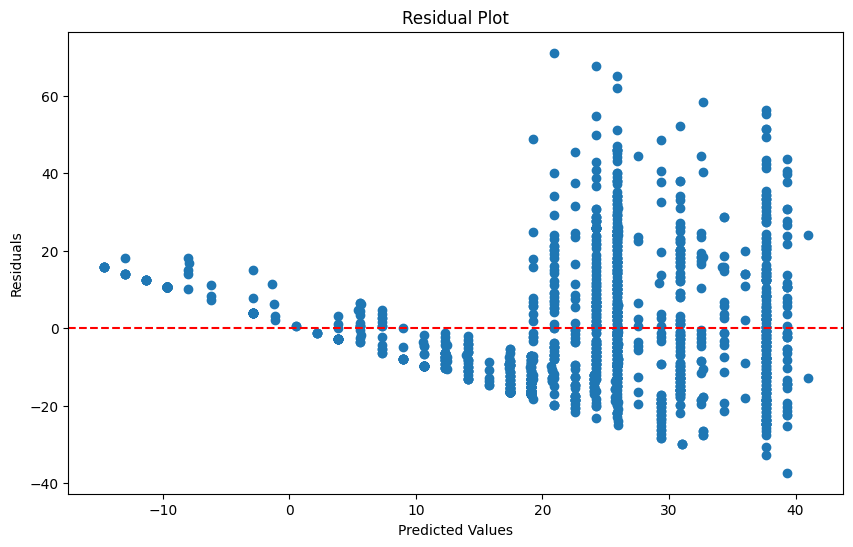

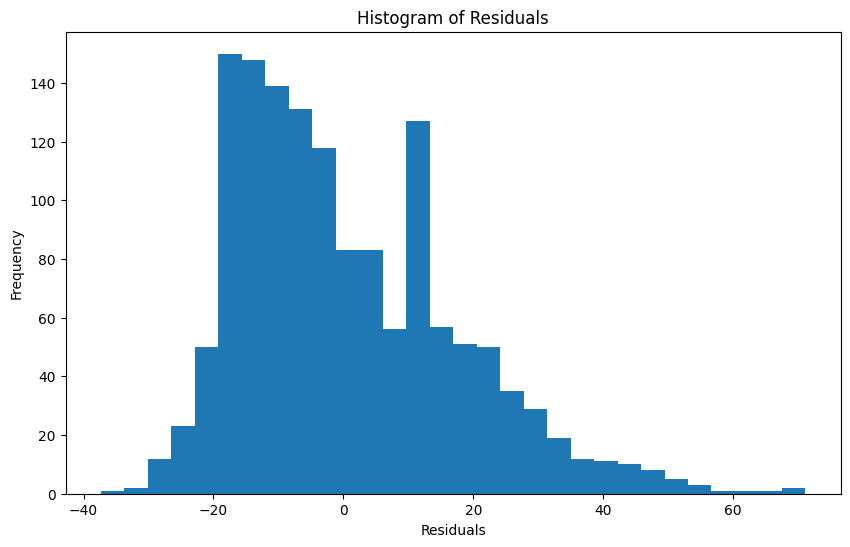

In [35]:
# Residual analysis
residuals = y_test - y_pred

# Plot the residuals against the predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# Plot a histogram of the residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

Not quite good enough fit, at least for prediction, time to retrain with other Regression modelling techniques and evaluate the best model for production

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

df_cleaner = df_clean.dropna(subset=["OSQ450", "LSQ565", "LSQ327"])

X = df_cleaner[["OSQ450", "LSQ565"]].values
y = df_cleaner["LSQ327"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results["Linear Regression"] = {
    "R2": r2_score(y_test, y_pred_lr),
    "MSE": mean_squared_error(y_test, y_pred_lr),
    "CV Mean R2": cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring="r2").mean()
}

# Polynomial Regression (degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)
results["Polynomial Regression (deg=2)"] = {
    "R2": r2_score(y_test, y_pred_poly),
    "MSE": mean_squared_error(y_test, y_pred_poly),
    "CV Mean R2": cross_val_score(lr_poly, X_train_poly, y_train, cv=5, scoring="r2").mean()
}

# Support Vector Regression
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
results["SVR"] = {
    "R2": r2_score(y_test, y_pred_svr),
    "MSE": mean_squared_error(y_test, y_pred_svr),
    "CV Mean R2": cross_val_score(svr, X_train_scaled, y_train, cv=5, scoring="r2").mean()
}

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # no scaling required
y_pred_rf = rf.predict(X_test)
results["Random Forest"] = {
    "R2": r2_score(y_test, y_pred_rf),
    "MSE": mean_squared_error(y_test, y_pred_rf),
    "CV Mean R2": cross_val_score(rf, X_train, y_train, cv=5, scoring="r2").mean()
}

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results["Gradient Boosting"] = {
    "R2": r2_score(y_test, y_pred_gb),
    "MSE": mean_squared_error(y_test, y_pred_gb),
    "CV Mean R2": cross_val_score(gb, X_train, y_train, cv=5, scoring="r2").mean()
}

# Print results
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")



Model: Linear Regression
R2: 0.3415
MSE: 283.4372
CV Mean R2: 0.3211

Model: Polynomial Regression (deg=2)
R2: 0.3828
MSE: 265.6308
CV Mean R2: 0.3619

Model: SVR
R2: 0.4544
MSE: 234.8233
CV Mean R2: 0.4349

Model: Random Forest
R2: 0.4956
MSE: 217.0945
CV Mean R2: 0.5009

Model: Gradient Boosting
R2: 0.4945
MSE: 217.5710
CV Mean R2: 0.5004


## Now build an optimally performant Neural Network Regression Model using Tensorflow

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 217.6791
Test MAE: 10.5134
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test R-squared: 0.4942


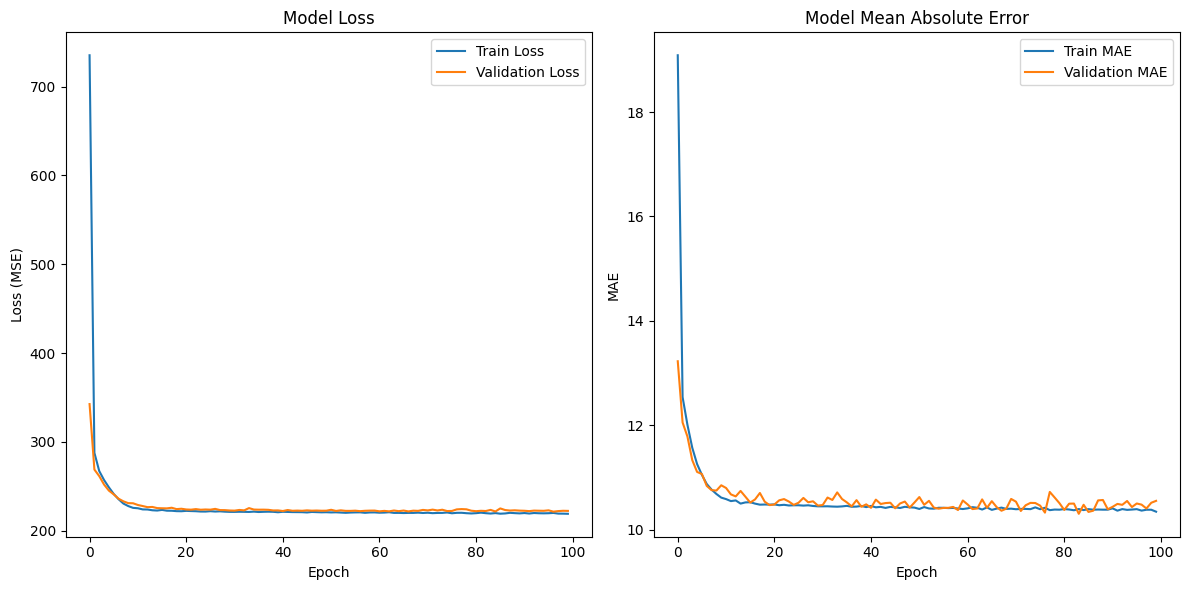

In [37]:
#!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define the model inputs and target
input = ["OSQ450", "LSQ565"]
target = 'LSQ327'

# Drop rows with missing values in the selected columns
df_numb_input_nulls = df_clean.dropna(subset=input + [target])

# Define features (X) and target (y)
X = df_numb_input_nulls[input]
y = df_numb_input_nulls[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add a scaler for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

# Make predictions
y_pred_nn = model.predict(X_test_scaled).flatten()

# Evaluate R-squared for comparison
r2_nn = r2_score(y_test, y_pred_nn)
print(f'Test R-squared: {r2_nn:.4f}')

# Plot training history (Loss and MAE)
plt.figure(figsize=(12, 6))

# Plot Loss Curve - shows how well the model is learning to minimise the loss function
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot MAE - shows the mean absolute error (average distance of residuals from model)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()



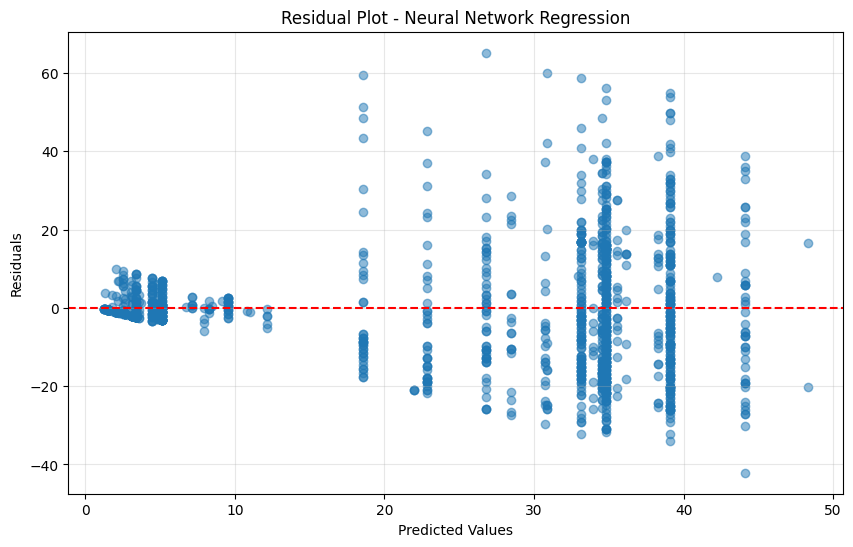

In [38]:
# Plot Residuals
residuals_nn = y_test - y_pred_nn

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_nn, residuals_nn, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Neural Network Regression')
plt.grid(True, alpha=0.3)
plt.show()


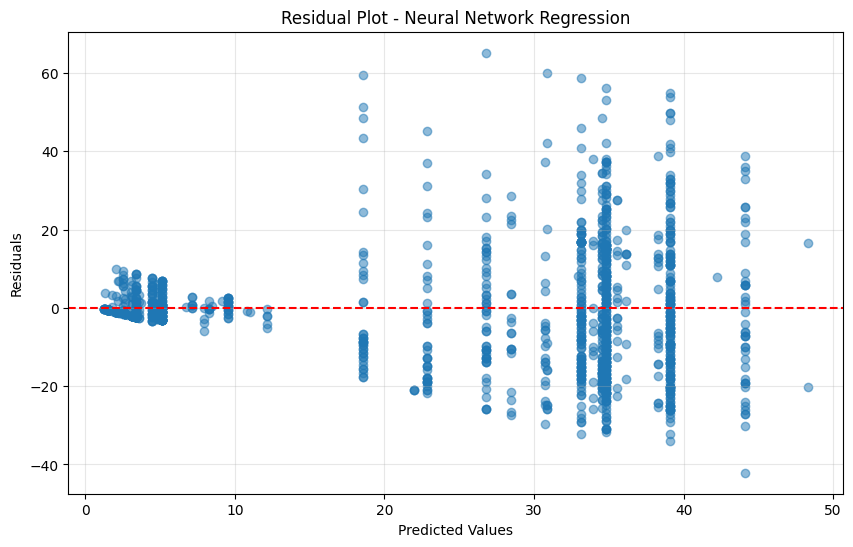

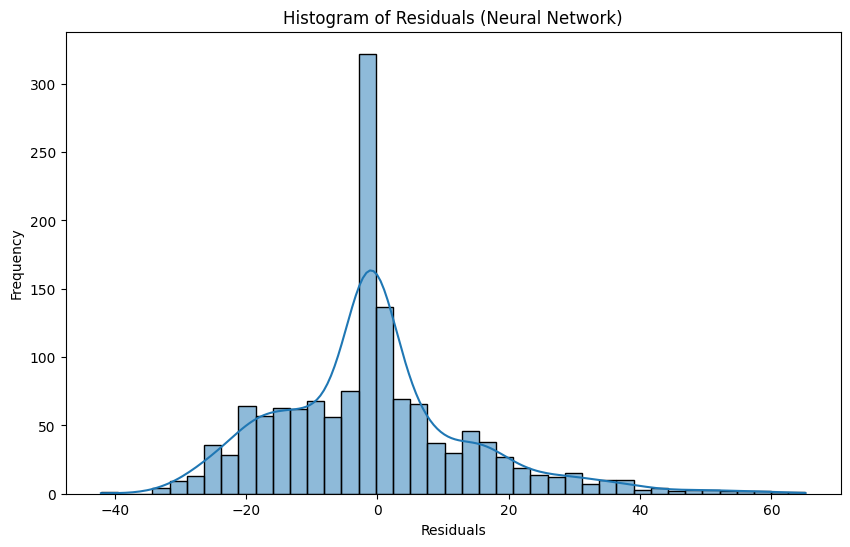

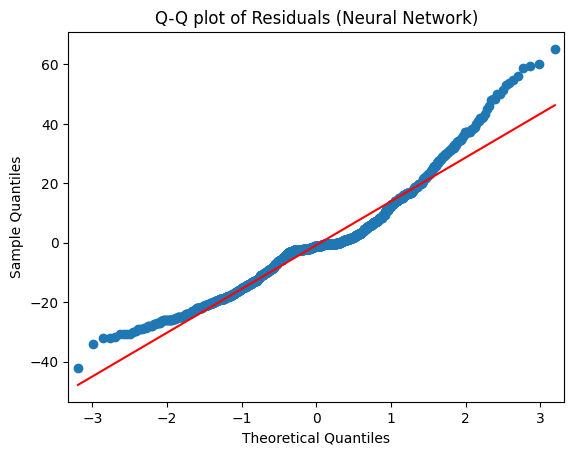

In [39]:
# Plot the residuals against the predicted values for Neural Network
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_nn, residuals_nn, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Neural Network Regression')
plt.grid(True, alpha=0.3)
plt.show()

# Plot histogram of residuals for Neural Network
plt.figure(figsize=(10, 6))
sns.histplot(residuals_nn, kde=True)
plt.title('Histogram of Residuals (Neural Network)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Quantile-Quantile plot (Q-Q plot) of residuals for Neural Network
sm.qqplot(residuals_nn, line='s') # 's' for standardized line
py.title('Q-Q plot of Residuals (Neural Network)')
py.show()

 # Impute missing values in input features using predictions from the Neural Networked model

- This assumes you trained your model on data where input features might have had missing values and you handled them (e.g., by dropping rows, but for prediction, imputation is better if needed)
- If the original training data (X_train) didn't have missing input values because you dropped rows, you might need to calculate the mean from the full df1 or a more representative subset.

- For consistency with the training approach of dropping rows with missing inputs, we will *only* predict for rows where input features are *not* null.

- If you need to predict for rows with missing inputs, you'd need to impute here.


In [40]:
# Identify rows in the original df1 where the target variable is null
df_to_predict = df1[df1[target].isnull()].copy()

if not df_to_predict.empty:
  # Select the input features for these rows
  X_predict = df_to_predict[input]


  # Filter rows where input features are not null for prediction
  X_predict_valid = X_predict.dropna(subset=input)
  predict_indices = X_predict_valid.index

  if not X_predict_valid.empty:
      # Scale the input features using the scaler fitted on the training data
      X_predict_scaled = scaler.transform(X_predict_valid)

      # Make predictions using the trained neural network model
      y_pred_all_nn = model.predict(X_predict_scaled).flatten()

      # Fill the missing values in the original dataframe with the predictions
      # Use .loc to ensure alignment by index
      df1.loc[predict_indices, target] = y_pred_all_nn

      print(f"Predicted and filled {len(y_pred_all_nn)} missing values in '{target}' column based on non-null input features.")
  else:
      print(f"No rows found in '{target}' with non-null input features {input} for prediction.")

else:
  print(f"No missing values found in the '{target}' column in df1. No predictions made.")

# Remaining Null count after inference via Regression NN model
print(f"\nNull count in '{target}' after filling: {df1[target].isnull().sum()}")

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted and filled 7914 missing values in 'LSQ327' column based on non-null input features.

Null count in 'LSQ327' after filling: 36947


In [45]:
len(y_pred_all_nn)

7914

In [41]:
df1.to_csv("cleaner_eqfx_customer_data.csv")
desc_df.to_csv("cleaner_headers.csv")

In [42]:
#SAVING the Model
import pickle

# Save the trained Random Forest model
filename = 'regression_NN_LSQ327.pkl'
pickle.dump(model, open(filename, 'wb'))

# Download the model file
from google.colab import files
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ALTERNATIVELY for keeping it in the GCP ecosystem

1. Uploading Dataframe to GCP
2. Uploading Model to GCP

## 1. UPLOADING Dataframe TO GCP
2 Options
1. Big Query client, load table form dataframe
2. Big Frames package's to_gbq() streamlines process.

In [43]:
#### OPTION 1 -- UPLOAD DF TO GCP ####

from google.cloud import bigquery

# Init BigQuery client
client = bigquery.Client()

# Define destination table
table_id = "your-project.your_dataset.your_table"

# Upload DataFrame
job = client.load_table_from_dataframe(df, table_id)
job.result()  # Wait for completion

print(f"Uploaded {job.output_rows} rows to {table_id}")

RefreshError: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x79cd10f67a50>)

In [ ]:
#### OPTION 2 -- UPLOAD DF to GCP ####

import bigframes.pandas as bpd

bdf = bpd.from_pandas(df)
bdf.to_gbq("your-project.your_dataset.your_table", if_exists="replace")

## 2. UPLOAD MODEL TO GCP
Two options

1.   Upload the trained model (.pkl, joblib) to Google Cloud Storage
2.   Register model with Vertex AI

In [ ]:
#UPLOAD TRAINED MODEL like .pkl and .joblib to GC Storage

from google.cloud import storage
import joblib

# Save model locally
joblib.dump(model, "model.pkl")

# Upload to GCS
client = storage.Client()
bucket = client.bucket("your-gcs-bucket")
blob = bucket.blob("models/model.pkl")
blob.upload_from_filename("model.pkl")

print("Model uploaded to GCS.")


In [ ]:
# REGISTER MODEL with VERTEX AI

from google.cloud import aiplatform

aiplatform.init(project="your-project", location="europe-west4")

model = aiplatform.Model.upload(
    display_name="my-model",
    artifact_uri="gs://your-gcs-bucket/models/",
    serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.0-24:latest"
)
